In [1]:
# 风险及免责提示：该策略由聚宽用户在聚宽社区分享，仅供学习交流使用。
# 原文一般包含策略说明，如有疑问请到原文和作者交流讨论。
# 原文网址：https://www.joinquant.com/view/community/detail/39054
# 标题：市场宽度——简洁版
# 作者：jqz1226

from jqdata import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import datetime
import warnings

warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['SimHei']  # 中文字体设置-黑体
plt.rcParams['axes.unicode_minus'] = False  # 解决保存图像是负号'-'显示为方块的问题

In [2]:
def display_mkt(df, p_vmax=100):
    fig = plt.figure(figsize=(16, count_))
    grid = plt.GridSpec(1, 10)
    cmap = sns.diverging_palette(200, 10, as_cmap=True)
    
    heatmap1 = fig.add_subplot(grid[:, :-1])
    heatmap1.xaxis.set_ticks_position('top')
    ax = sns.heatmap(df[df.columns[:-1]], vmin=0, vmax=100, annot=True, fmt="d", cmap=cmap,
                annot_kws={'size': 10}, cbar=False)
    ax.set_yticklabels(df.index.strftime('%Y-%m-%d'))
    
    heatmap2 = fig.add_subplot(grid[:, -1])
    heatmap2.xaxis.set_ticks_position('top')
    sns.heatmap(df[[df.columns[-1]]], vmin=0,
                vmax=p_vmax, # 方案差异点
                annot=True, fmt="d", cmap=cmap, annot_kws={'size': 10})

    plt.yticks([])
    plt.show()
    # 显示折线图
    plt.style.use({'figure.figsize': (16, 8)})
    df[df.columns[-1]].plot()

In [3]:
def display_mkt2(df, p_vmax=100):
    """
    只显示总体列，而不显示各个行业
    """
    fig = plt.figure(figsize=(16, count_))
    grid = plt.GridSpec(1, 10)
    cmap = sns.diverging_palette(200, 10, as_cmap=True)
    
    heatmap2 = fig.add_subplot(grid[:, -1])
    heatmap2.xaxis.set_ticks_position('top')
    df_tot = df[[df.columns[-1]]]
    ax = sns.heatmap(df_tot, vmin=0,
                vmax=p_vmax, # 方案差异点
                annot=True, fmt="d", cmap=cmap, annot_kws={'size': 10})
    ax.set_yticklabels(df_tot.index.strftime('%Y-%m-%d'))

    plt.show()

### 指定参数

In [4]:
end_date = '2022-09-02'  # 计算截止日
count_ = 20 # 计算天数

### 一、 准备数据

In [5]:
by_date = get_trade_days(end_date=end_date,count=count_+20)[0]
stock_list = get_all_securities(date=by_date).index.tolist()  # count_+20个交易日之前就已经上市的
#
df_close = get_price(stock_list, end_date=end_date, count=count_+20, fields='close', panel=False
                    ).pivot(index='time', values='close', columns='code')
df_bias = df_close.iloc[20:] > df_close.rolling(20).mean().iloc[20:]  # C > MA20

In [6]:
df_bias.tail()

code,000001.XSHE,000002.XSHE,000004.XSHE,000005.XSHE,000006.XSHE,000007.XSHE,000008.XSHE,000009.XSHE,000010.XSHE,000011.XSHE,000012.XSHE,000014.XSHE,000016.XSHE,000017.XSHE,000019.XSHE,000020.XSHE,000021.XSHE,000023.XSHE,000025.XSHE,000026.XSHE,000027.XSHE,000028.XSHE,000029.XSHE,000030.XSHE,000031.XSHE,000032.XSHE,000034.XSHE,000035.XSHE,000036.XSHE,000037.XSHE,000038.XSHE,000039.XSHE,000040.XSHE,000042.XSHE,000045.XSHE,000046.XSHE,000048.XSHE,000049.XSHE,000050.XSHE,000055.XSHE,...,688682.XSHG,688683.XSHG,688685.XSHG,688686.XSHG,688687.XSHG,688689.XSHG,688690.XSHG,688696.XSHG,688697.XSHG,688698.XSHG,688699.XSHG,688700.XSHG,688701.XSHG,688707.XSHG,688711.XSHG,688718.XSHG,688722.XSHG,688728.XSHG,688733.XSHG,688737.XSHG,688739.XSHG,688766.XSHG,688767.XSHG,688768.XSHG,688772.XSHG,688776.XSHG,688777.XSHG,688778.XSHG,688779.XSHG,688786.XSHG,688787.XSHG,688788.XSHG,688789.XSHG,688793.XSHG,688798.XSHG,688799.XSHG,688800.XSHG,688819.XSHG,688981.XSHG,689009.XSHG
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-08-29,True,False,False,True,True,False,False,False,True,False,False,True,True,False,True,True,False,False,False,False,True,True,False,False,True,False,False,False,True,True,False,False,True,True,True,False,False,True,False,True,...,False,True,False,True,False,False,True,False,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,True,True,False,False
2022-08-30,True,True,False,True,True,True,True,False,True,False,False,True,True,False,True,False,False,False,False,True,True,True,False,False,True,False,False,False,True,True,False,False,False,True,True,True,False,True,False,True,...,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False
2022-08-31,True,True,False,True,True,True,False,False,True,False,False,True,True,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False
2022-09-01,True,True,False,False,True,True,False,False,True,True,False,True,False,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,True,False,False,False,True,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
2022-09-02,True,True,False,False,True,True,False,False,True,False,False,True,True,False,True,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,...,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False


### 二、 按行业汇总

In [7]:
df_industries = get_industries('sw_l1', date=end_date)
df_industries.head()

,name,start_date
801740,国防军工I,2014-02-21
801110,家用电器I,2004-02-10
801160,公用事业I,2004-02-10
801770,通信I,2014-02-21
801010,农林牧渔I,2004-02-09


In [8]:
df=pd.DataFrame()
columns = set(df_bias.columns)
for idx, row in df_industries.iterrows():
    ind_stocks = set(get_industry_stocks(idx, date=end_date))  # 行业成分股
    ind_avail_stocks = list(columns & ind_stocks) # 成分股 在df_bias表中存在的
    if ind_avail_stocks:
        # 计算该行业成分股C>MA20的百分比，技巧：df_bias[ind_avail_stocks]
        df[row['name']] = (100*(df_bias[ind_avail_stocks].sum(axis=1))/len(ind_avail_stocks)).astype(int)
#
df.sort_index(ascending=False, inplace=True)

In [9]:
df.head()

,国防军工I,家用电器I,公用事业I,通信I,农林牧渔I,食品饮料I,计算机I,有色金属I,机械设备I,煤炭I,美容护理I,环保I,交通运输I,建筑材料I,银行I,石油石化I,纺织服装I,房地产I,传媒I,商业贸易I,综合I,汽车I,轻工制造I,建筑装饰I,电子I,非银金融I,化工I,休闲服务I,医药生物I,电气设备I,钢铁I
time,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2022-09-02,15,24,19,36,72,47,17,2,11,31,48,25,47,26,76,51,47,62,72,63,41,11,54,41,11,40,19,61,36,7,8
2022-09-01,6,19,17,14,63,59,9,1,6,44,27,18,46,26,66,42,36,66,54,57,25,6,40,37,6,41,15,52,30,5,8
2022-08-31,5,19,18,16,65,68,7,4,7,31,41,23,50,20,80,42,36,42,71,54,33,8,45,41,7,66,18,59,27,8,8
2022-08-30,12,36,60,28,86,61,15,18,22,89,55,49,73,34,69,76,59,67,80,73,45,17,66,52,17,79,35,72,37,27,28
2022-08-29,14,35,81,22,87,63,12,23,27,94,37,49,70,34,50,78,57,49,65,68,54,22,59,50,17,76,45,66,33,36,26


### 三、图形显示
有三种显示方案可以选择

#### 方案一：直接加总各行业及格率

这是雷公的原始方案。该方案表面上看是简单地汇总了各个行业的及格率，但在图形化显示时，通过赋予了vmax，让不同的值显示出不同的颜色。

关键是参数vmax。多少个行业，每个行业的及格率最大值可达100，所以汇总后，总体的最大值顶格(vmax)=行业数*100

显示时，heatmap根据各个值相对于vmax的水平，赋予了表示冷暖的不同颜色。

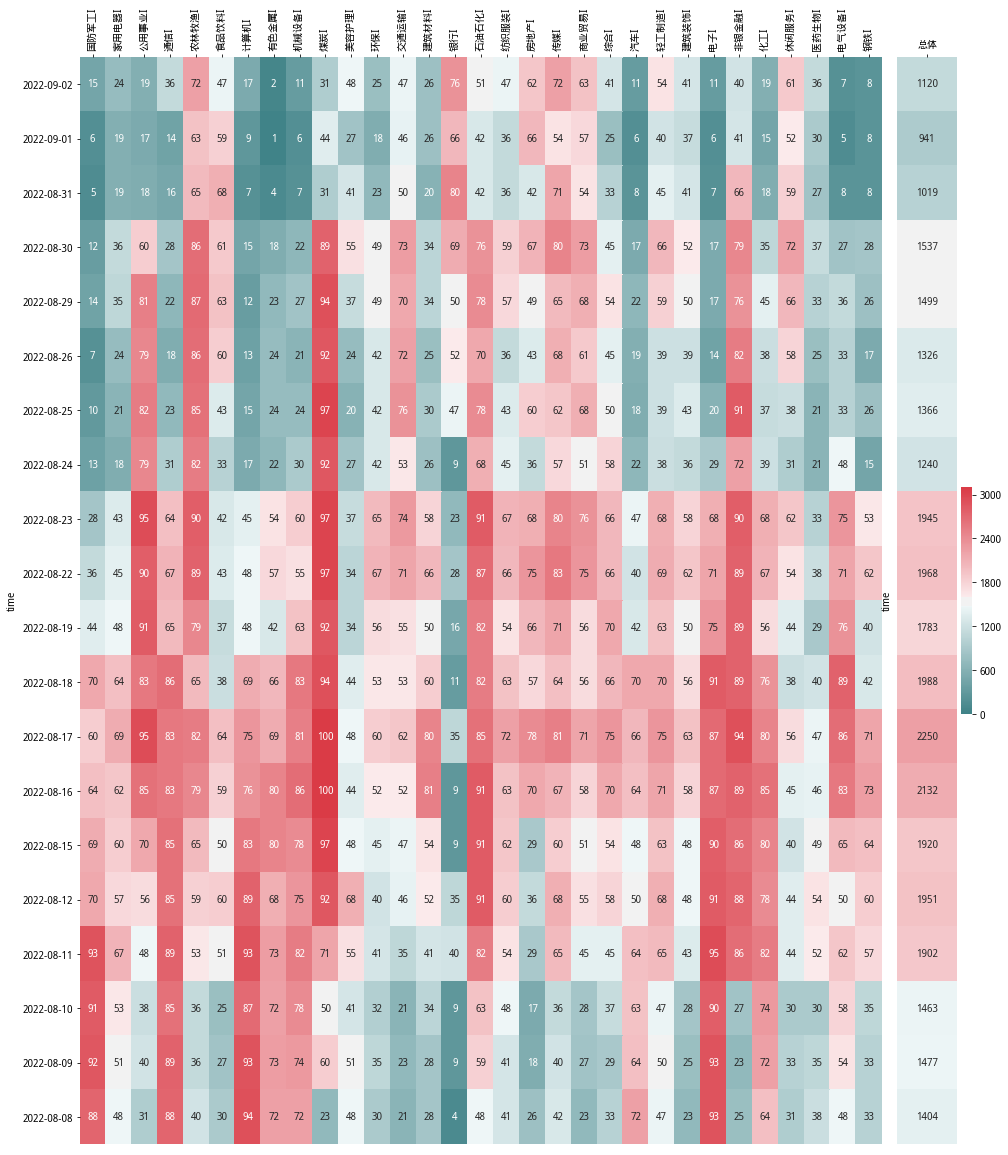

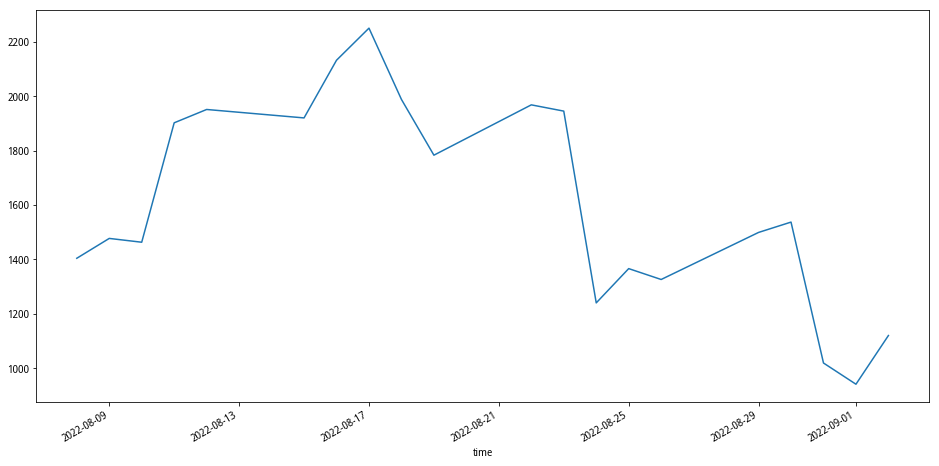

In [10]:
df_1 = df.copy(deep=True)   # 为不破坏原数据，以比较3种方案，所以先copy
vmax=len(df.columns) * 100

# 方案 1：各行业的及格率 再汇总
df_1['总体']=df_1.sum(axis=1)
display_mkt(df_1, p_vmax=vmax)  

#### 方案二：行业及格率的再评均
方案二是方案一的延续。方案1的汇总数——“总体”，会显示出大大小小的数字，这数字究竟意味着什么？

前面已经解释过了，在图形展示时，这些值会按照相对于vmax的水平，显示出不同颜色。

既然如此，方案二就试图直截了当，去求行业及格率的再平均数，在“总体”这一列中显示相对百分比值，而不是绝对值。

举个例子。申万一级行业31个，每个行业的及格率都可能到100，所以汇总后，可能的最大值(vmax)是3100，而2022年9月2日的及格率加总是1127，而1127/3100=36%，那就在“总体”列中直接显示36。表示居于vmax的36%水平。

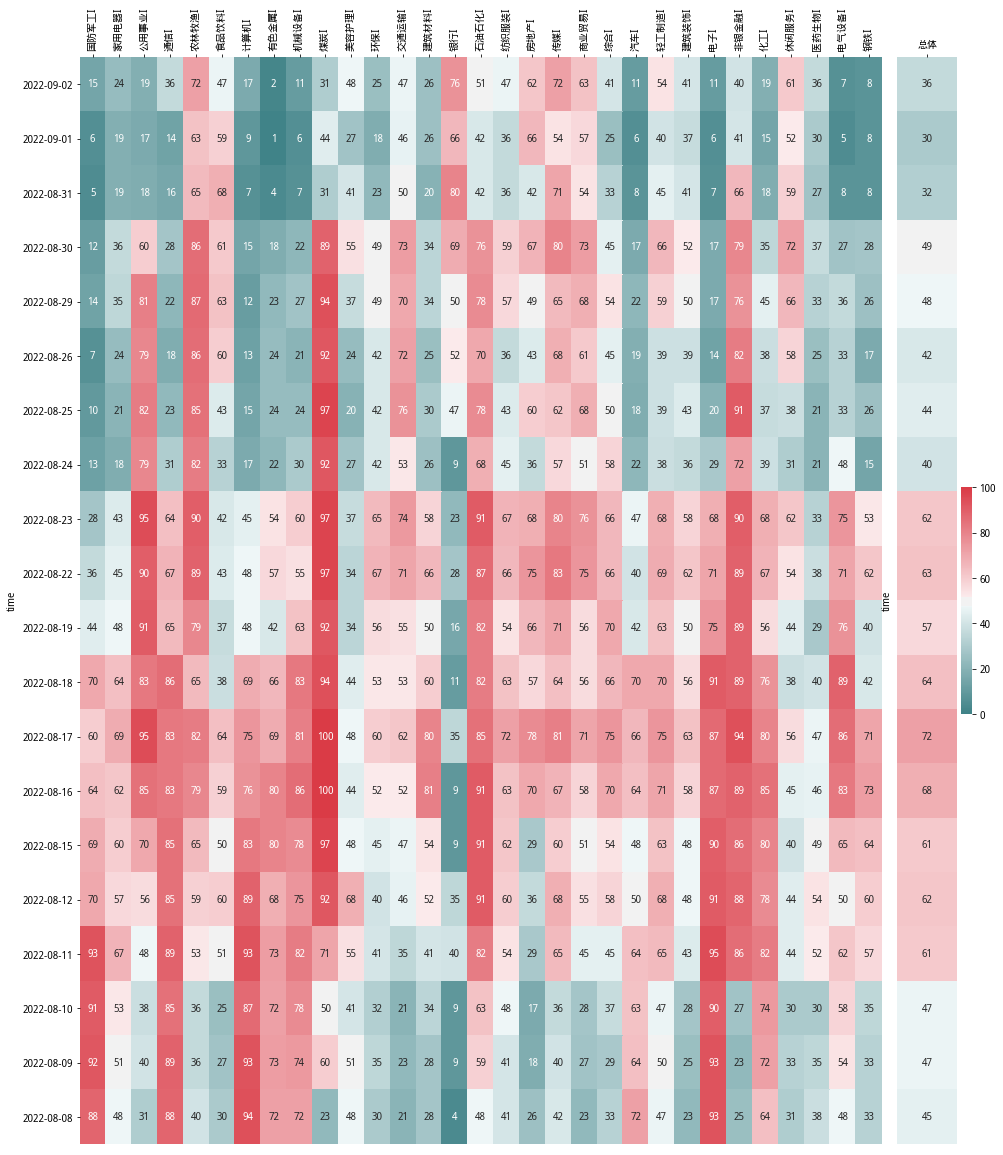

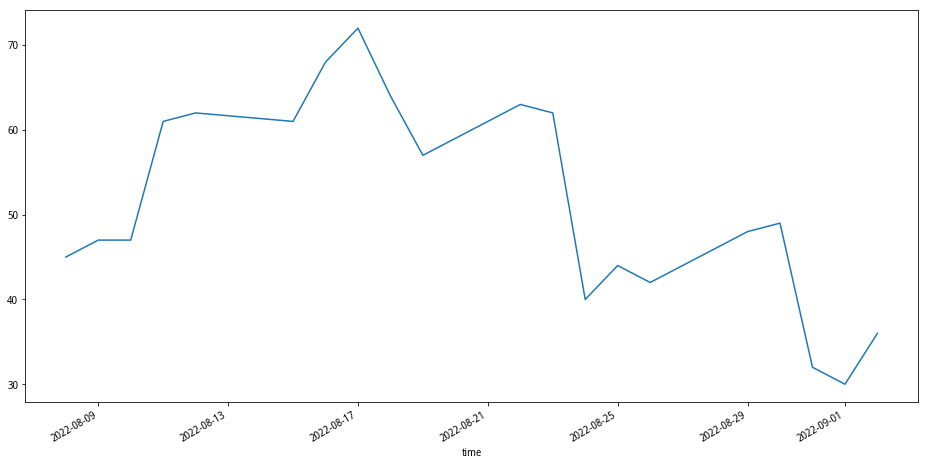

In [11]:
df_2 = df.copy(deep=True)
# 方案 2
df_2['总体']=(df_2.sum(axis=1)/len(df_2.columns)).astype(int)  # 方案3
display_mkt(df_2, p_vmax=100)

#### 方案三:市场整体比例

这是我设想的：不区分行业，直接计算所有股票C>MA20的比例。这样图形既显示了分行业的及格率，也显示了市场整体的及格率。

例如，2022-9-2，合格的股票共4654只，其中及格的（Close>MA20）是1360只，1360/4654=29%，于是“总体”显示为29。

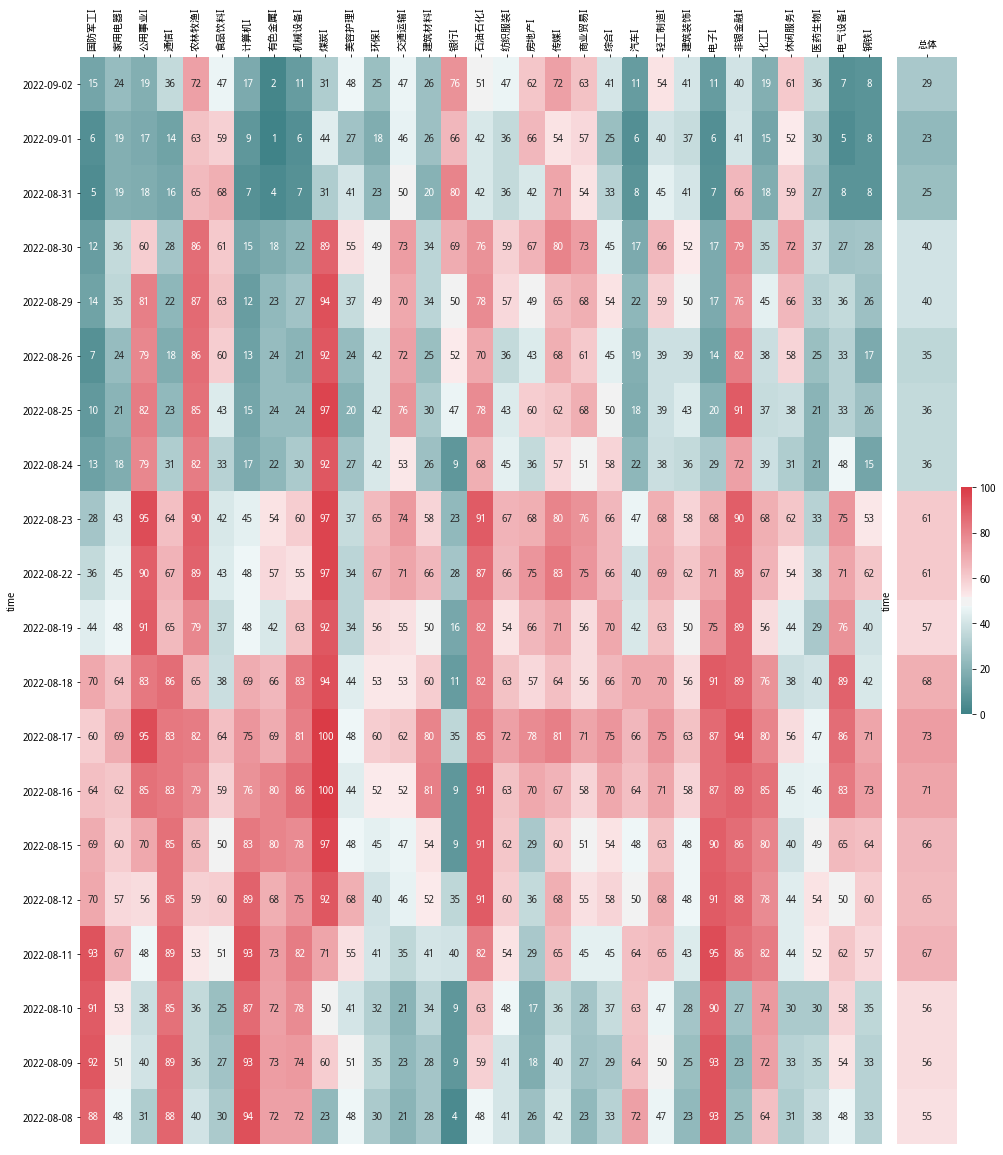

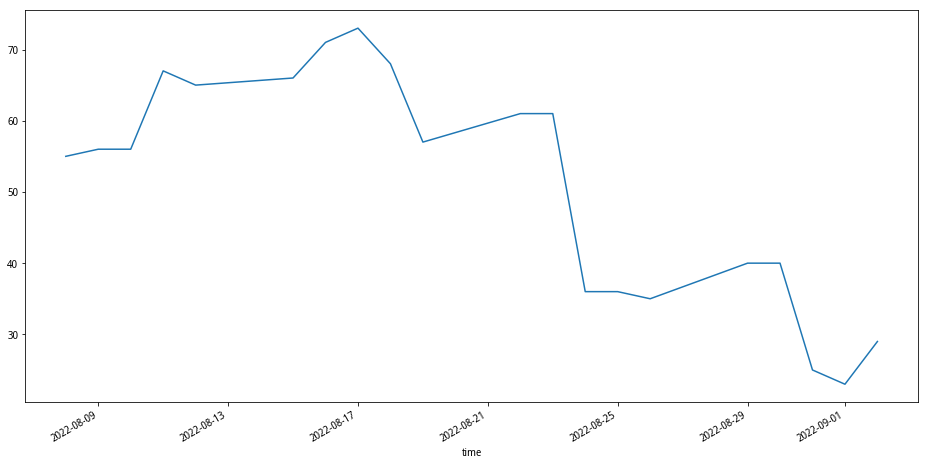

In [12]:
df_3 = df.copy(deep=True)
# 方案 3
df_3['总体']=(100*df_bias.sum(axis=1)/len(df_bias.columns)).astype(int)
display_mkt(df_3, p_vmax=100)  # v_max：最大值顶格100